ref:
https://github.com/abhisheksuran/Reinforcement_Learning/blob/master/Td3.py  
gym:https://www.gymlibrary.dev/environments/box2d/lunar_lander/

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
%%time
%%capture
!pip install swig
!pip install gymnasium[box2d] ## python 3.11은 gym[box2d]문제 있음
import gymnasium as gym  ###

CPU times: user 3.47 s, sys: 1.29 s, total: 4.77 s
Wall time: 56.2 s


Wall time: 53.7 s



In [4]:
import gym
import tensorflow as tf
import keras
from keras import layers
from keras.regularizers import l2 as L2
import numpy as np
import random
from collections import deque

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

# LunarLander_Continuous Environment

In [5]:
problem = "LunarLanderContinuous-v2"  ###
env = gym.make(problem)

num_states = env.observation_space.shape[0]      # 8
ps(env.observation_space,'Shape of State Space') #(8,)
p(env.observation_space,'env.observation_space')
print(f'state_low::{env.observation_space.low}')
print(f'state_high::{env.observation_space.high}\n')

num_actions = env.action_space.shape[0] # 2
ps(env.action_space,'Shape of Action Space') #(2,)
p(env.action_space,'env.action_space')
print(f'action_low::{env.action_space.low}')
print(f'action_high::{env.action_space.high}\n')

state = env.reset()
p(state,'state') #(8,)

<<Shape of State Space>> Shape(8,)
<<env.observation_space>>:
Shape:(8,)
Type: <class 'gym.spaces.box.Box'>
Values: Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
state_low::[-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ]
state_high::[1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ]

<<Shape of Action Space>> Shape(2,)
<<env.action_space>>:
Shape:(2,)
Type: <class 'gym.spaces.box.Box'>
Values: Box(-1.0, 1.0, (2,), float32)
action_low::[-1. -1.]
action_high::[1. 1.]

<<state>>:
Shape:(8,)
Type: <class 'numpy.ndarray'>
Values: [ 0.00176907  1.4222516   0.17918041  0.5036133  -0.00204319 -0.04058706
  0.          0.        ]


\[env.observation_space]:Shape:(8,)    
Type: <class 'gym.spaces.box.Box'>   
Values: Box(   
 [-1.5  -1.5   -5.   -5.  -3.1415927  -5.   -0.  -0. ],  
 [1.5   1.5     5.    5.   3.1415927   5.    1.   1. ], (8,), float32 )     
state_low:: [-1.5  -1.5    -5.   -5.   -3.1415927 -5.   -0.   -0. ]  
state_high:: [1.5    1.5     5.    5.    3.1415927 5.     1.   1. ]    

\[env.action_space]: Shape:(2,)    
Type: <class 'gym.spaces.box.Box'>  
Values: Box(-1.0, 1.0, (2,), float32)  
action_low::[-1. -1.]  
action_high::[1. 1.]    

\[state]:  Shape:(8,)    
Type: <class 'numpy.ndarray'>  
Values: [-0.0064477 1.4049095 -0.6530905 -0.2671648  0.00747799 0.14793481 0.   0. ]  

# Replay Buffer

In [ ]:
class RBuffer():
  def __init__(self, maxsize, statedim, naction):
    self.cnt = 0
    self.maxsize = maxsize
    self.state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.action_memory = np.zeros((maxsize, naction), dtype=np.float32)
    self.reward_memory = np.zeros((maxsize,), dtype=np.float32)
    self.next_state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.not_done_memory = np.zeros((maxsize,), dtype=bool)

  def record(self, state, action, reward, next_state, done):
    index = self.cnt % self.maxsize
    self.state_memory[index] = state
    self.action_memory[index] = action
    self.reward_memory[index] = reward
    self.next_state_memory[index] = next_state
    self.not_done_memory[index] = 1 - done
    self.cnt += 1

  def get_batch(self, batch_size):
    max_mem = min(self.cnt, self.maxsize)
    batch = np.random.choice(max_mem, batch_size, replace= False)
    states = tf.convert_to_tensor(self.state_memory[batch], dtype= tf.float32)
    actions = tf.convert_to_tensor(self.action_memory[batch], dtype= tf.float32)
    rewards = tf.convert_to_tensor(self.reward_memory[batch], dtype= tf.float32)
    next_states = tf.convert_to_tensor(self.next_state_memory[batch], dtype= tf.float32)
    not_dones = tf.convert_to_tensor(self.not_done_memory[batch], dtype= tf.float32)
    return states, actions, rewards, next_states, not_dones

# TD3

## Actor-Network, Critic-Network

In [ ]:
nodes = 256 #512

def Critic():
    in_s = layers.Input(shape=(num_states,))
    in_a = layers.Input(shape=(num_actions,))
    x = layers.concatenate([in_s, in_a])
    x = layers.Dense(nodes, activation='relu',activity_regularizer=L2(0.0001))(x)
    x = layers.Dense(nodes, activation='relu',activity_regularizer=L2(0.0001))(x)
    x = layers.Dense(1, activation='linear')(x)
    return keras.Model(inputs=[in_s, in_a], outputs=x)

def Actor():
    in_s = layers.Input(shape=(num_states,))
    x = layers.Dense(nodes, activation='relu',activity_regularizer=L2(0.0001))(in_s)
    x = layers.Dense(nodes, activation='relu',activity_regularizer=L2(0.0001))(x)
    x = layers.Dense(num_actions, activation='tanh')(x)
    return keras.Model(inputs=in_s, outputs=x)

actor = Actor()
actor.summary()
critic = Critic()
critic.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,610 (268.01 KB)

 Trainable params: 68,610 (268.01 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 8)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 2)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 10)             │              0 │ input_layer_1[0][0],   │
│                           │                        │                │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 256)            │          2,816 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 256)            │         65,792 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 1)              │            257 │ dense_4[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 68,865 (269.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 0 (0.00 B)

## TD3 Agent

In [ ]:
class TD3Agent():
  def __init__(self, env, n_RBuffer, batch_size=64):
    self.memory = RBuffer(n_RBuffer, num_states, num_actions)
    self.actor_main = Actor()
    self.actor_target = Actor()
    self.critic_main = Critic()
    self.critic_main2 = Critic()
    self.critic_target = Critic()
    self.critic_target2 = Critic()
    # Network Copy
    self.update_target(self.actor_target, self.actor_main, 1.0)
    self.update_target(self.critic_target, self.critic_main, 1.0)
    self.update_target(self.critic_target2, self.critic_main2, 1.0)

    # Network Optimization definition
    self.a_lr = 0.001
    self.c_lr = 0.002
    self.a_opt = tf.keras.optimizers.Adam(self.a_lr)
    self.c_opt1 = tf.keras.optimizers.Adam(self.c_lr)
    self.c_opt2 = tf.keras.optimizers.Adam(self.c_lr)

    # Action space
    self.n_actions = len(env.action_space.high) # 2
    self.min_action = env.action_space.low[0]   # -1.0
    self.max_action = env.action_space.high[0]  # 1.0

    ### Hyper Parameters ###
    self.batch_size = batch_size
    self.actor_update_steps = 2
    self.warmup = 2000 #1000  #(Iterations)
    self.gamma = 0.99
    self.tau = 0.02 #0.005
    self.expl_noise = 0.1 #0.1
    self.warmup_noise = 1.0

    self.train_step = 0 # Iterations
    self.loss_q = 0
    self.loss_a = 0
    self.losses = []
    self.a_n_rate = 0

  ## Soft Update
  @tf.function
  def update_target(self,target_model, source_model, tau):
      for target_var, source_var in zip(target_model.trainable_variables,\
                                        source_model.trainable_variables):
          target_var.assign(tau * source_var + (1 - tau) * target_var)

  ## Get Action
  def get_action(self, state, get ='main'):
      if get == 'main' :  # get actor_main(call from maim loop)
          action = self.actor_main(state)
          if self.train_step < self.warmup : # warmup mode
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.warmup_noise)
          else:
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
              noise = tf.clip_by_value(noise, -0.5, 0.5)
      else :              # get actor_target(call form train loop)
          action = self.actor_target(state)
          noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
          noise = tf.clip_by_value(noise, -0.5, 0.5)
      action = tf.clip_by_value(action+noise, -1, 1)
      self.a_n_rate = self.a_n_rate * 0.9 + 0.1 * tf.reduce_mean(noise**2)/tf.reduce_mean(action**2)
      return action

  def train(self):
      if self.memory.cnt < self.batch_size: return
      states, actions, rewards, next_states, not_dones = self.memory.get_batch(self.batch_size)
      next_actions = self.get_action(next_states, get='target') # from actor_target
      ## CriticMain Network Update
      loss_q = self.train_step_critic(states, actions, rewards, next_states, not_dones, next_actions)
      self.loss_q = self.loss_q*0.5 + loss_q*0.5
      self.train_step += 1
      ## ActorMain Net. Update & Actor/Critic Target Net. Update
      if self.train_step % self.actor_update_steps == 0:
          loss_a = self.train_step_actor(states)
          self.loss_a = self.loss_a*0.5 + loss_a*0.5
          ## ActorTarget update
          self.update_target(self.actor_target, self.actor_main, self.tau)
          ## CriticTarget update
          self.update_target(self.critic_target, self.critic_main, self.tau)
          self.update_target(self.critic_target2, self.critic_main2, self.tau)
      self.losses.append([self.loss_a,self.loss_q])

  @tf.function
  def train_step_critic(self, states, actions, rewards, next_states, not_dones, next_actions):
      with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
          target_q1 = tf.squeeze(self.critic_target([next_states, next_actions]), 1)
          target_q2 = tf.squeeze(self.critic_target2([next_states, next_actions]), 1)
          target_q =  tf.math.minimum(target_q1, target_q2)
          target_q = rewards + self.gamma * target_q * not_dones
          critic_value = tf.squeeze(self.critic_main([states, actions]), 1)
          critic_value2 = tf.squeeze(self.critic_main2([states, actions]), 1)
          loss_q1 = tf.keras.losses.MSE(target_q, critic_value)
          loss_q2 = tf.keras.losses.MSE(target_q, critic_value2)
      grads1 = tape1.gradient(loss_q1, self.critic_main.trainable_variables)
      grads2 = tape2.gradient(loss_q2, self.critic_main2.trainable_variables)
      self.c_opt1.apply_gradients(zip(grads1, self.critic_main.trainable_variables))
      self.c_opt2.apply_gradients(zip(grads2, self.critic_main2.trainable_variables))
      return  loss_q1+loss_q2

  @tf.function
  def train_step_actor(self, states):
      with tf.GradientTape() as tape:
          new_policy_actions = self.actor_main(states)
          loss_a = -self.critic_main([states, new_policy_actions])
          loss_a = tf.math.reduce_mean(loss_a)
      grads = tape.gradient(loss_a, self.actor_main.trainable_variables)
      self.a_opt.apply_gradients(zip(grads, self.actor_main.trainable_variables))
      return loss_a

## Training

In [ ]:
def ma_loss(n=10): # average loss
    if len(agent.losses) <n : return 0,0
    a = np.array(agent.losses[-1])[0]
    q = np.array(agent.losses[-n:])[:,1]
    q_ret = np.cumsum(q, dtype=np.float32)
    return a, q_ret[-1] / n

In [ ]:
ep_reward = []
total_avgr = []
steps = []
ep_losses = []
total_avgr_best = 0
step_limit = 600 #800 2000

def main_loop(episodes=10):
    global ep_reward, total_avgr, steps
    global total_avgr_best, step_limit

    ep_reward.clear()
    total_avgr.clear()
    steps.clear()

    for s in range(episods):
      episodic_reward = 0
      state = env.reset()
      done = False
      step_cnt = 0
      while (not done) and (step_cnt <= step_limit):
        action = agent.get_action(state.reshape(1,-1), get ='main')[0] # from actor_main
        next_state, reward, done, info = env.step(action)
#        if step_cnt == step_limit : reward_p += -100  ####
        agent.memory.record(state, action, reward, next_state, done)
        agent.train() ###
        state = next_state
        episodic_reward += reward
        step_cnt += 1
      ep_losses.append([agent.loss_a,agent.loss_q])
      ep_reward.append(episodic_reward)
      avg_reward = np.mean(ep_reward[-5:])
      total_avgr.append(avg_reward)
      steps.append(step_cnt)
      loss_a, loss_q = ma_loss()
      print(f'Epis(steps):{s:03d}({step_cnt:04d}), reward:{episodic_reward:.2f}, avg reward:{avg_reward:.2f}',end="")
      print(f', RB.cnt:{agent.memory.cnt}, Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}',end="")
      print(f' Loss(a,q):{loss_a:.1f}, {loss_q:.1f}, noise/action:{agent.a_n_rate:0.2f}')

In [ ]:
%%time
# Hyper Parameters
batch_size = 256 #64 #128 256
n_RBuffer = 20000 #5000 #10000 20000

problem = "LunarLanderContinuous-v2"  ###
env = gym.make(problem)
agent = TD3Agent(env, n_RBuffer, batch_size=batch_size)

episods = 10
main_loop(episods)

Epis(steps):000(0096), reward:-348.09, avg reward:-348.09, RB.cnt:96, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0, 0.0, noise/action:1.75
Epis(steps):001(0093), reward:-140.13, avg reward:-244.11, RB.cnt:189, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0, 0.0, noise/action:1.77


Epis(steps):002(0075), reward:-375.69, avg reward:-287.97, RB.cnt:264, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0, 0.0, noise/action:1.01
Epis(steps):003(0237), reward:-763.59, avg reward:-406.88, RB.cnt:501, Cnt_limit:600, BatchSize:256 Loss(a,q):10.7, 18.8, noise/action:0.44
Epis(steps):004(0127), reward:-313.52, avg reward:-388.20, RB.cnt:628, Cnt_limit:600, BatchSize:256 Loss(a,q):12.8, 12.6, noise/action:0.46
Epis(steps):005(0105), reward:-360.38, avg reward:-390.66, RB.cnt:733, Cnt_limit:600, BatchSize:256 Loss(a,q):14.7, 14.6, noise/action:0.90
Epis(steps):006(0105), reward:-83.05, avg reward:-379.25, RB.cnt:838, Cnt_limit:600, BatchSize:256 Loss(a,q):12.5, 10.4, noise/action:1.17
Epis(steps):007(0140), reward:-560.09, avg reward:-416.13, RB.cnt:978, Cnt_limit:600, BatchSize:256 Loss(a,q):13.8, 6.3, noise/action:0.86
Epis(steps):008(0232), reward:0.54, avg reward:-263.30, RB.cnt:1210, Cnt_limit:600, BatchSize:256 Loss(a,q):10.2, 7.4, noise/action:0.36
Epis(steps):009(0089), rewa

## Evaluation

In [ ]:
def ma(a, n=3): # moving average
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [ ]:
def plot_graph():
    global agent
    global nodes, n_RBuffer
    global ep_reward, total_avgr, steps
    global total_avgr_best, step_limit
    losses = np.array(agent.losses)
    skips = int(len(losses)/len(ep_reward))
    loss_tot = ma(losses[:,0],n=25)+ma(losses[:,1],n=25)
    loss_tot = loss_tot[::skips].copy()

    conditions = f'hidden_nodes:{nodes}, n_RBuffer:{n_RBuffer}, \
    actor_update_steps:{agent.actor_update_steps}, warmup:{agent.warmup}\n\
    tau:{agent.tau},a_lr:{agent.a_lr},c_lr:{agent.c_lr}, \
    Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}'

    plt.figure(figsize=(10,3))
    plt.subplot(121)

    plt.title(f"Reward Vs Episods\n{conditions}")
    plt.plot(ep_reward,label='reward')
    plt.plot(total_avgr,label='avg_reward')
    plt.plot(np.array(steps)/4-600,label='step/Epi.',linewidth=0.8)
    plt.plot(loss_tot-800,label='loss_total',linewidth=0.8)
    plt.xlabel("Episods")
    plt.ylim(-1000,300)
    plt.grid()
    plt.legend()

    plt.subplot(122)
    plt.plot(losses[:,1],label='loss_critic',linewidth=1)
    plt.plot(ma(losses[:,1],n=7),label='ma(loss_critic)',linewidth=0.3)
    plt.plot(losses[:,0],label='loss_actor',linewidth=1)
    plt.title("Loss")
    plt.xlabel("Iterations")
    plt.ylim(-100,400)
    plt.grid()
    plt.legend()
    plt.show()

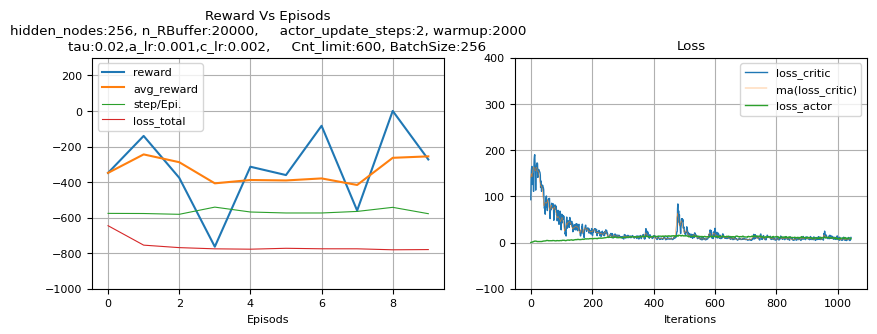

In [ ]:
plot_graph()

In [ ]:
%%time
# Hyper Parameters
batch_size = 256 #64 #128 256
n_RBuffer = 20000 #5000 #10000 20000

problem = "LunarLanderContinuous-v2"  ###
env = gym.make(problem)
agent = TD3Agent(env, n_RBuffer, batch_size=batch_size)

### Hyper Parameters ###
agent.actor_update_steps = 2
agent.warmup = 2000 #1000  #(Iterations)
agent.gamma = 0.99
agent.tau = 0.02 #0.005
agent.expl_noise = 0.1 #0.1
agent.warmup_noise = 1.0

episods = 55 #100 #500
main_loop(episods)

Epis(steps):000(0154), reward:-211.23, avg reward:-211.23, RB.cnt:154, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0, 0.0, noise/action:1.48
Epis(steps):001(0165), reward:-535.03, avg reward:-373.13, RB.cnt:319, Cnt_limit:600, BatchSize:256 Loss(a,q):2.9, 23.2, noise/action:0.68
Epis(steps):002(0099), reward:-241.35, avg reward:-329.20, RB.cnt:418, Cnt_limit:600, BatchSize:256 Loss(a,q):2.3, 22.5, noise/action:0.67
Epis(steps):003(0233), reward:-357.67, avg reward:-336.32, RB.cnt:651, Cnt_limit:600, BatchSize:256 Loss(a,q):2.1, 14.4, noise/action:0.55
Epis(steps):004(0286), reward:-232.25, avg reward:-315.50, RB.cnt:937, Cnt_limit:600, BatchSize:256 Loss(a,q):3.9, 16.5, noise/action:1.35
Epis(steps):005(0160), reward:-347.97, avg reward:-342.85, RB.cnt:1097, Cnt_limit:600, BatchSize:256 Loss(a,q):5.9, 26.6, noise/action:1.68
Epis(steps):006(0189), reward:-140.27, avg reward:-263.90, RB.cnt:1286, Cnt_limit:600, BatchSize:256 Loss(a,q):7.5, 35.4, noise/action:0.73
Epis(steps):007(0601), rew

Epis(steps):054(0600), reward:56.25, **avg reward:112.84**, RB.cnt:13889, Cnt_limit:600, BatchSize:256 Loss(a,q):-49.4, 46.4, noise/action:0.01
Wall time: 3min 55s

In [ ]:
plot_graph()

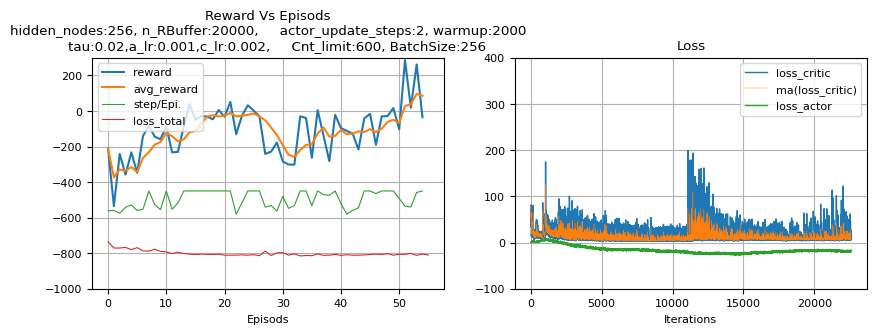

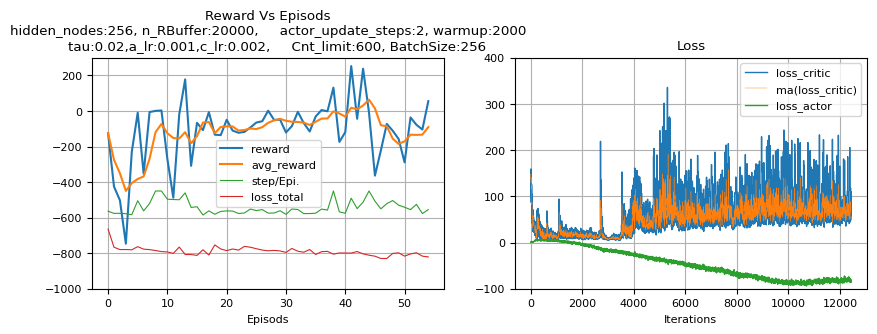

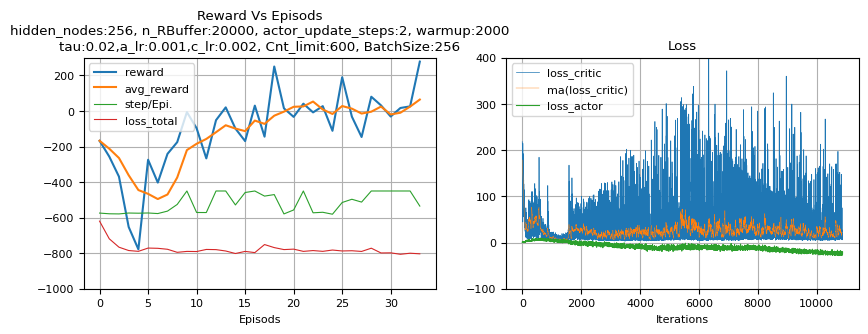

### cirtic_learning rate 변경 : 0.0005, 0.002  
>hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:2000  
>tau:0.02,a_lr:0.001,c_lr:****, Cnt_limit:600, BatchSize:256

**c_lr:0.0005**     
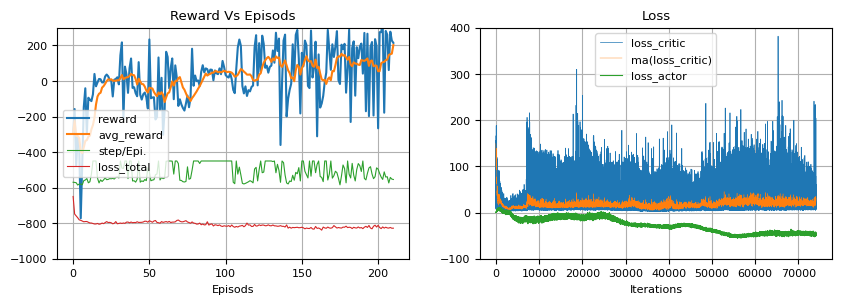

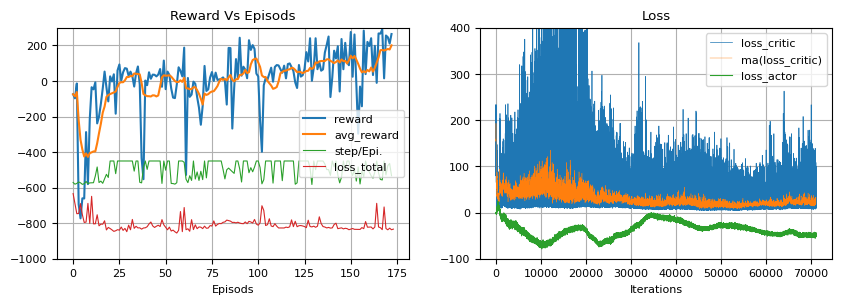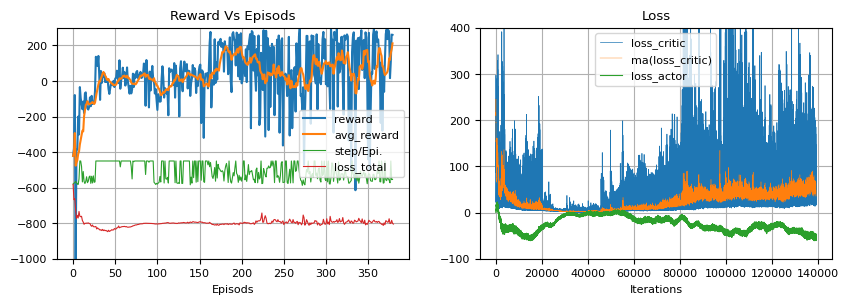

**c_lr:0.002**     
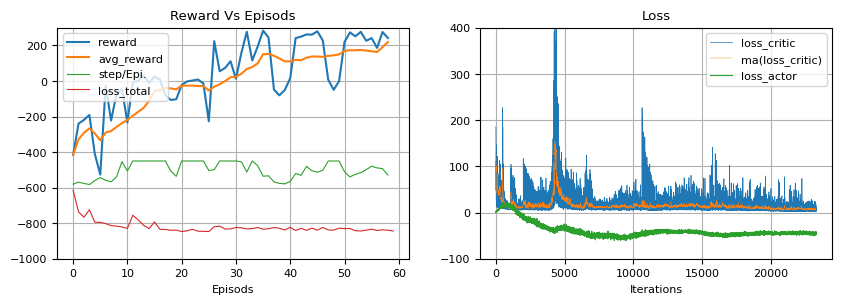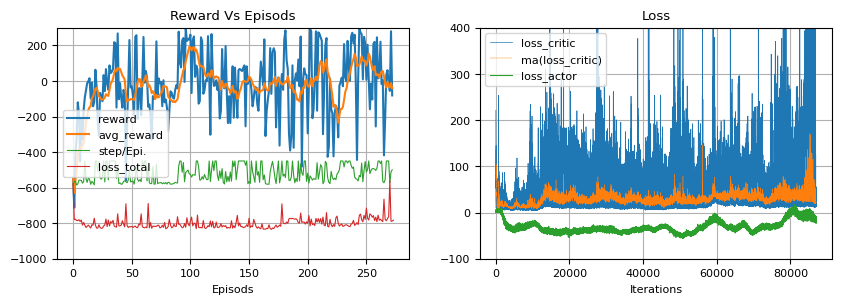

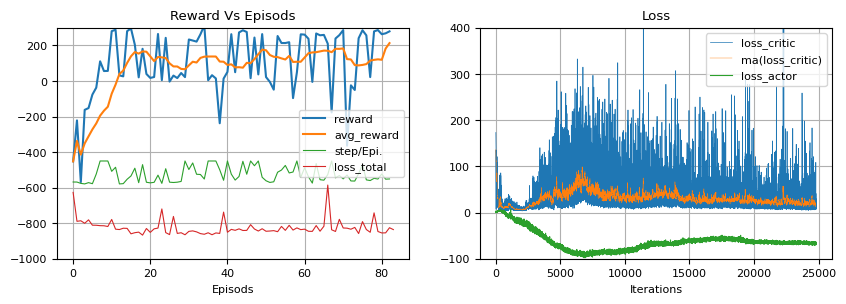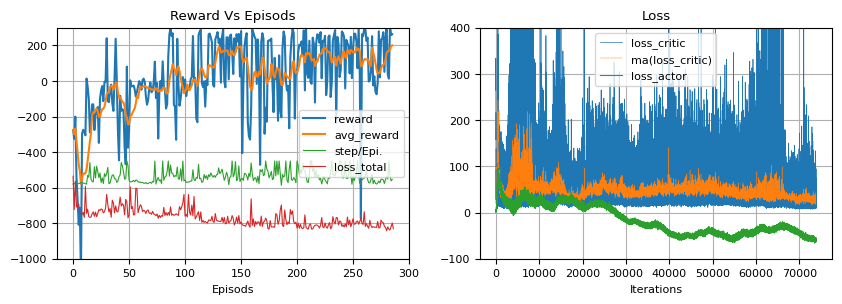

### tau값이 커지면 critic loss의 변동성이 증가   
> hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:1000
> tau:0.05,a_lr:0.001,c_lr:0.002, Cnt_limit:600, BatchSize:256

**tau:0.005 : total loss가 감소하지 못하고 있음, 너무 작은가?**  


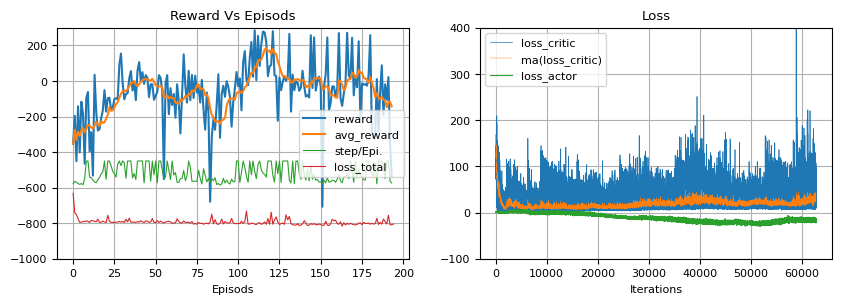

tau:0.01  
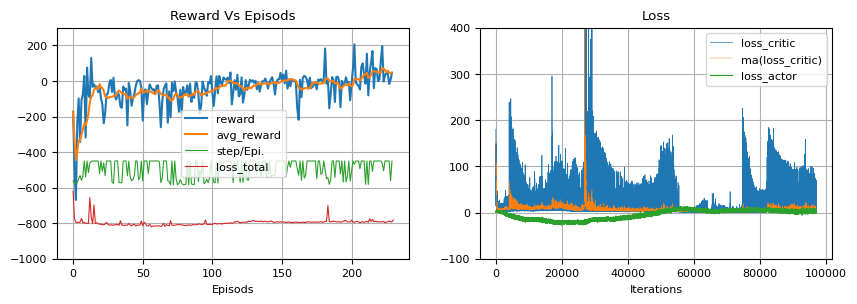

tau:0.05  
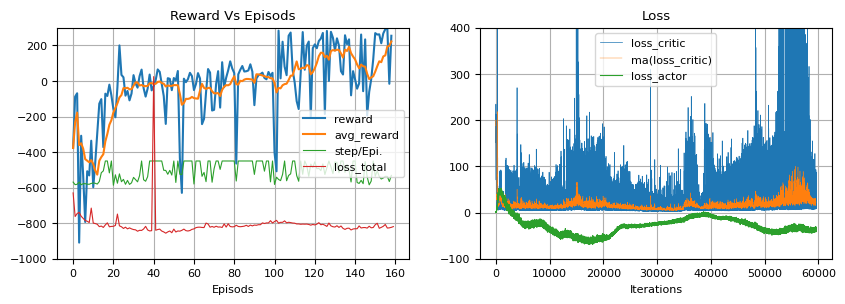

### 동일한 hyper parameter에서 학습 변동성  
**avg_reward >200 또는 episodes > 500 일때 까지 학습**

n_RBuffer:5000  
hidden_nodes:256, n_RBuffer:5000, actor_update_steps:2, warmup:200
tau:0.05,a_lr:0.0001,c_lr:0.0001, Cnt_limit:600, BatchSize:64  
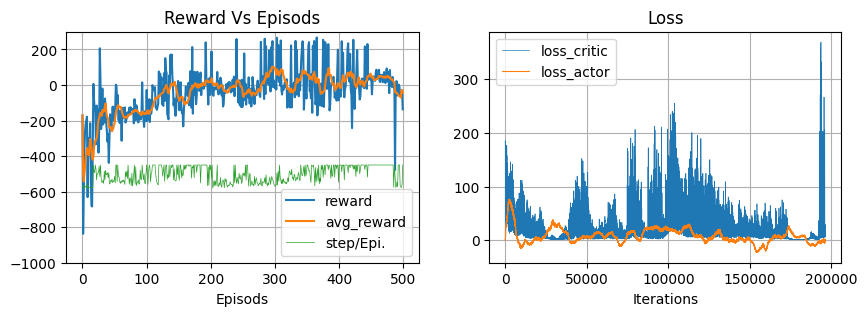

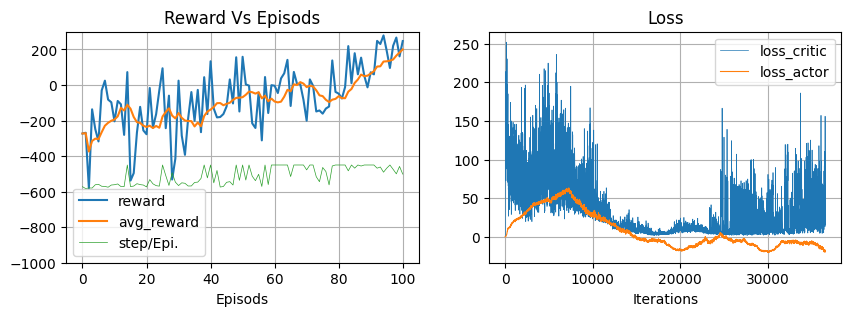


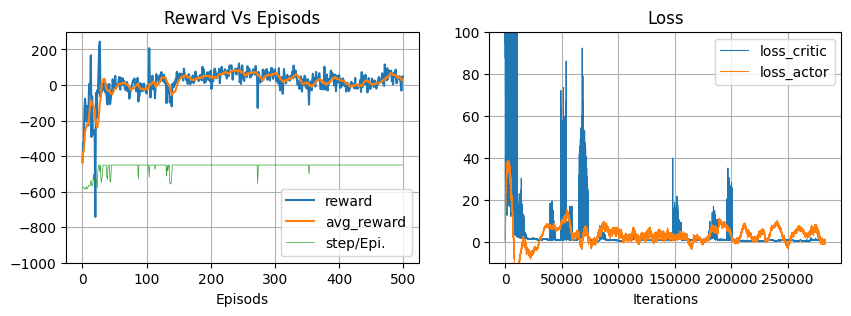

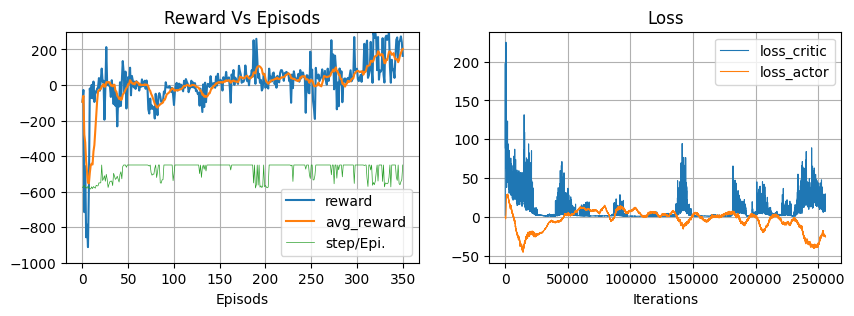

### BatchSize 변경 : 128, 64

**n_RBuffer:20000**  
hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:100  
tau:0.05,a_lr:0.0001,c_lr:0.0001,BatchSize:64  
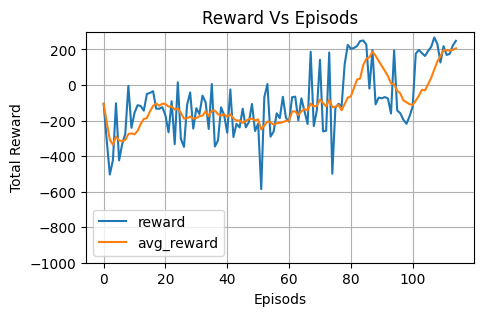

BatchSize:128   
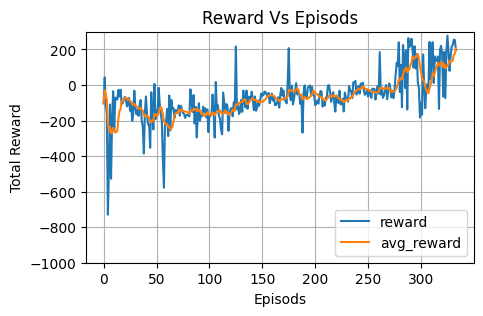

### RBuffer size와 step_limit 관계 검토


**step_limit설정으로 학습시간 조정**

while (not done):  **Episode 실행시간 대폭 증가할 수 있음**
>Episodes(steps):114(1084),Wall time: 11min 30s  
>**Episodes(steps):190(1071),Wall time: 43min 36s**   

while (not done) and (cnt < 800):     
>**Episodes(steps):492(294),Wall time: 45min 57s**  
Episodes(steps):350(0600), Wall time: 44min 27s  
Epis(steps):100(0395), Wall time: 11min 11s  
Epis(steps):149(0319), Wall time: 16min 49s


**n_RBuffer:5000, step_limit 제거**    
-    **Buffer가 너무 작음: 좋은 경험이 삭제됨**   
-    **step 크기 확인**   
    while (not done): # and (cnt < 800):   
    Episodes(steps):260(**11553**), reward:-2077.43, avg reward:-453.90, RB.cnt:157943, BatchSize:64   
    Episodes(steps):296(**3860**), reward:-438.76, avg reward:119.34, RB.cnt:184539, BatchSize:64    
    Episodes(steps):306(**2363**), reward:-106.59, avg reward:213.49, RB.cnt:189784, BatchSize:64    

hidden_nodes:256, n_RBuffer:5000, actor_update_steps:2, warmup:100  
tau:0.05,a_lr:0.0001,c_lr:0.0001,BatchSize:64  

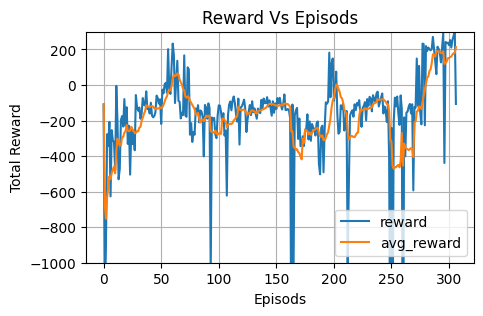

**n_RBuffer:20000:늘려도 부족한 경우가 발생함**  
hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:100  
tau:0.05,a_lr:0.0001,c_lr:0.0001,BatchSize:64  
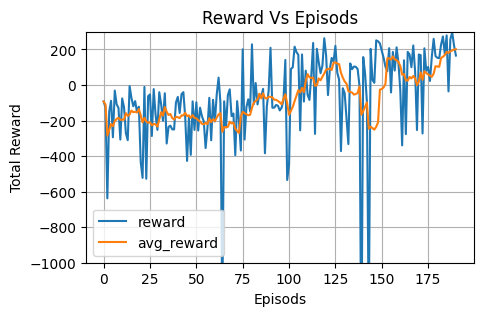

    while (not done) and (step_cnt < 600):

hidden_nodes:256, n_RBuffer:5000, actor_update_steps:2, warmup:100  
tau:0.05,a_lr:0.0001,c_lr:0.0001,BatchSize:64  
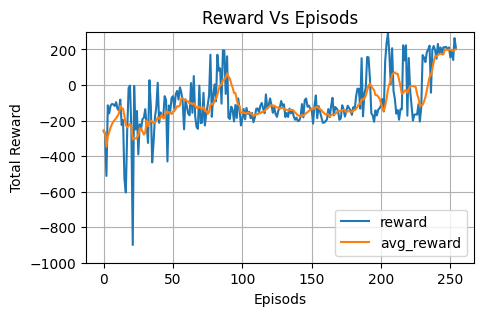  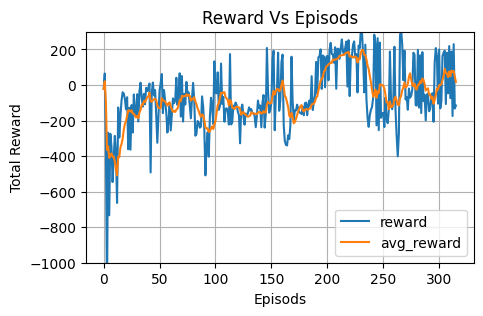

## Test

In [ ]:
problem = "LunarLanderContinuous-v2"  ###
env = gym.make(problem)
#env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")

In [ ]:
total_reward = 0
state = env.reset()
done = False
cnt = 0
while not done:
    action = agent.actor_main(state.reshape(1,8))
    next_state, reward, done, _, _ = env.step(action[0])
    state = next_state
    total_reward += reward
    cnt += 1
    if done:
       print(f'cnt:{cnt},reward:{total_reward}')

In [ ]:
%%capture
!pip install gym pyvirtualdisplay
!apt-get install -y python-opengl ffmpeg
!apt install chromium-browser xvfb

In [ ]:
%%time
%%capture
!pip install gym pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env_v3, render_as_image_v3

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env_v3(env, path=path, name_prefix="TD3-LundarLander")
state,_ = env_v.reset()
cnt = 0
while True:
    render_as_image_v3(env_v,step=cnt)
    action = agent.actor_main(state.reshape(1,8))
    state, reward, done, info = env_v.step(action[0])
    if done:  break;
    cnt += 1
env.close()

In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

/content/gdrive/MyDrive/Colab Notebooks/video/TD3-LundarLander-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

/content/gdrive/MyDrive/Colab Notebooks/video/TD3-LundarLander-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

/content/gdrive/MyDrive/Colab Notebooks/video/TD3-LundarLander-episode-0.mp4


# 실습과제 : Hyper Parameter tuning    
#### n_episode = 100 으로 고정하고,  
#### learning_rate = 0.01, 0.005, 0.0001, ?   
#### tau = 0.009, 0.05, 0.03, 0.01, 1, ?   
#### batch_size = 32, 64, 128, 256, ?  
#### n_RBuffer = 5000, 10000, 20000, ?  
#### Warmup = 100, 200, ?  

# 실습과제 2 : Ablation study     
## TD3 - DP - TPS - CDQ = DDPQ style  
#### Delayed policy update  
#### * self.actor_update_steps = 2 수정      
#### Target policy smoothing  
#### * target_actions += tf.clip_by_value( target_noise, -0.5, 0.5 )  
#### Clipped Double Q-learning  
#### * Clitic Net. 1, 2 --> Single Clitic Net.  